# CH04_Q9: Regression
This question involves the use of multiple linear regression on the Auto data set.

In [11]:
import pandas as pd
from ISLP import load_data
pd.set_option('display.max_columns', None) 

In [13]:
Auto = load_data('Auto')

In [17]:
Auto.shape

(392, 8)

In [21]:
Auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


mpg: The higher the value, the more fuel-efficient it is.
cylinders: The more cylinders there are, the more powerful the engine is.
displacement: The larger the displacement, the more powerful the engine will usually be.
horsepower: The more horsepower a car has, the better its acceleration and top speed will generally be.
acceleration: The smaller the value, the better the car's acceleration performance
origin: 1 means USA, 2 means Europe, 3 means Japan.

In [15]:
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


#(a) Produce a scatterplot matrix which includes all of the variables in the data set.

In [31]:
Auto.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
dtype: int64

In [27]:
Auto.isnull().any()

mpg             False
cylinders       False
displacement    False
horsepower      False
weight          False
acceleration    False
year            False
origin          False
dtype: bool

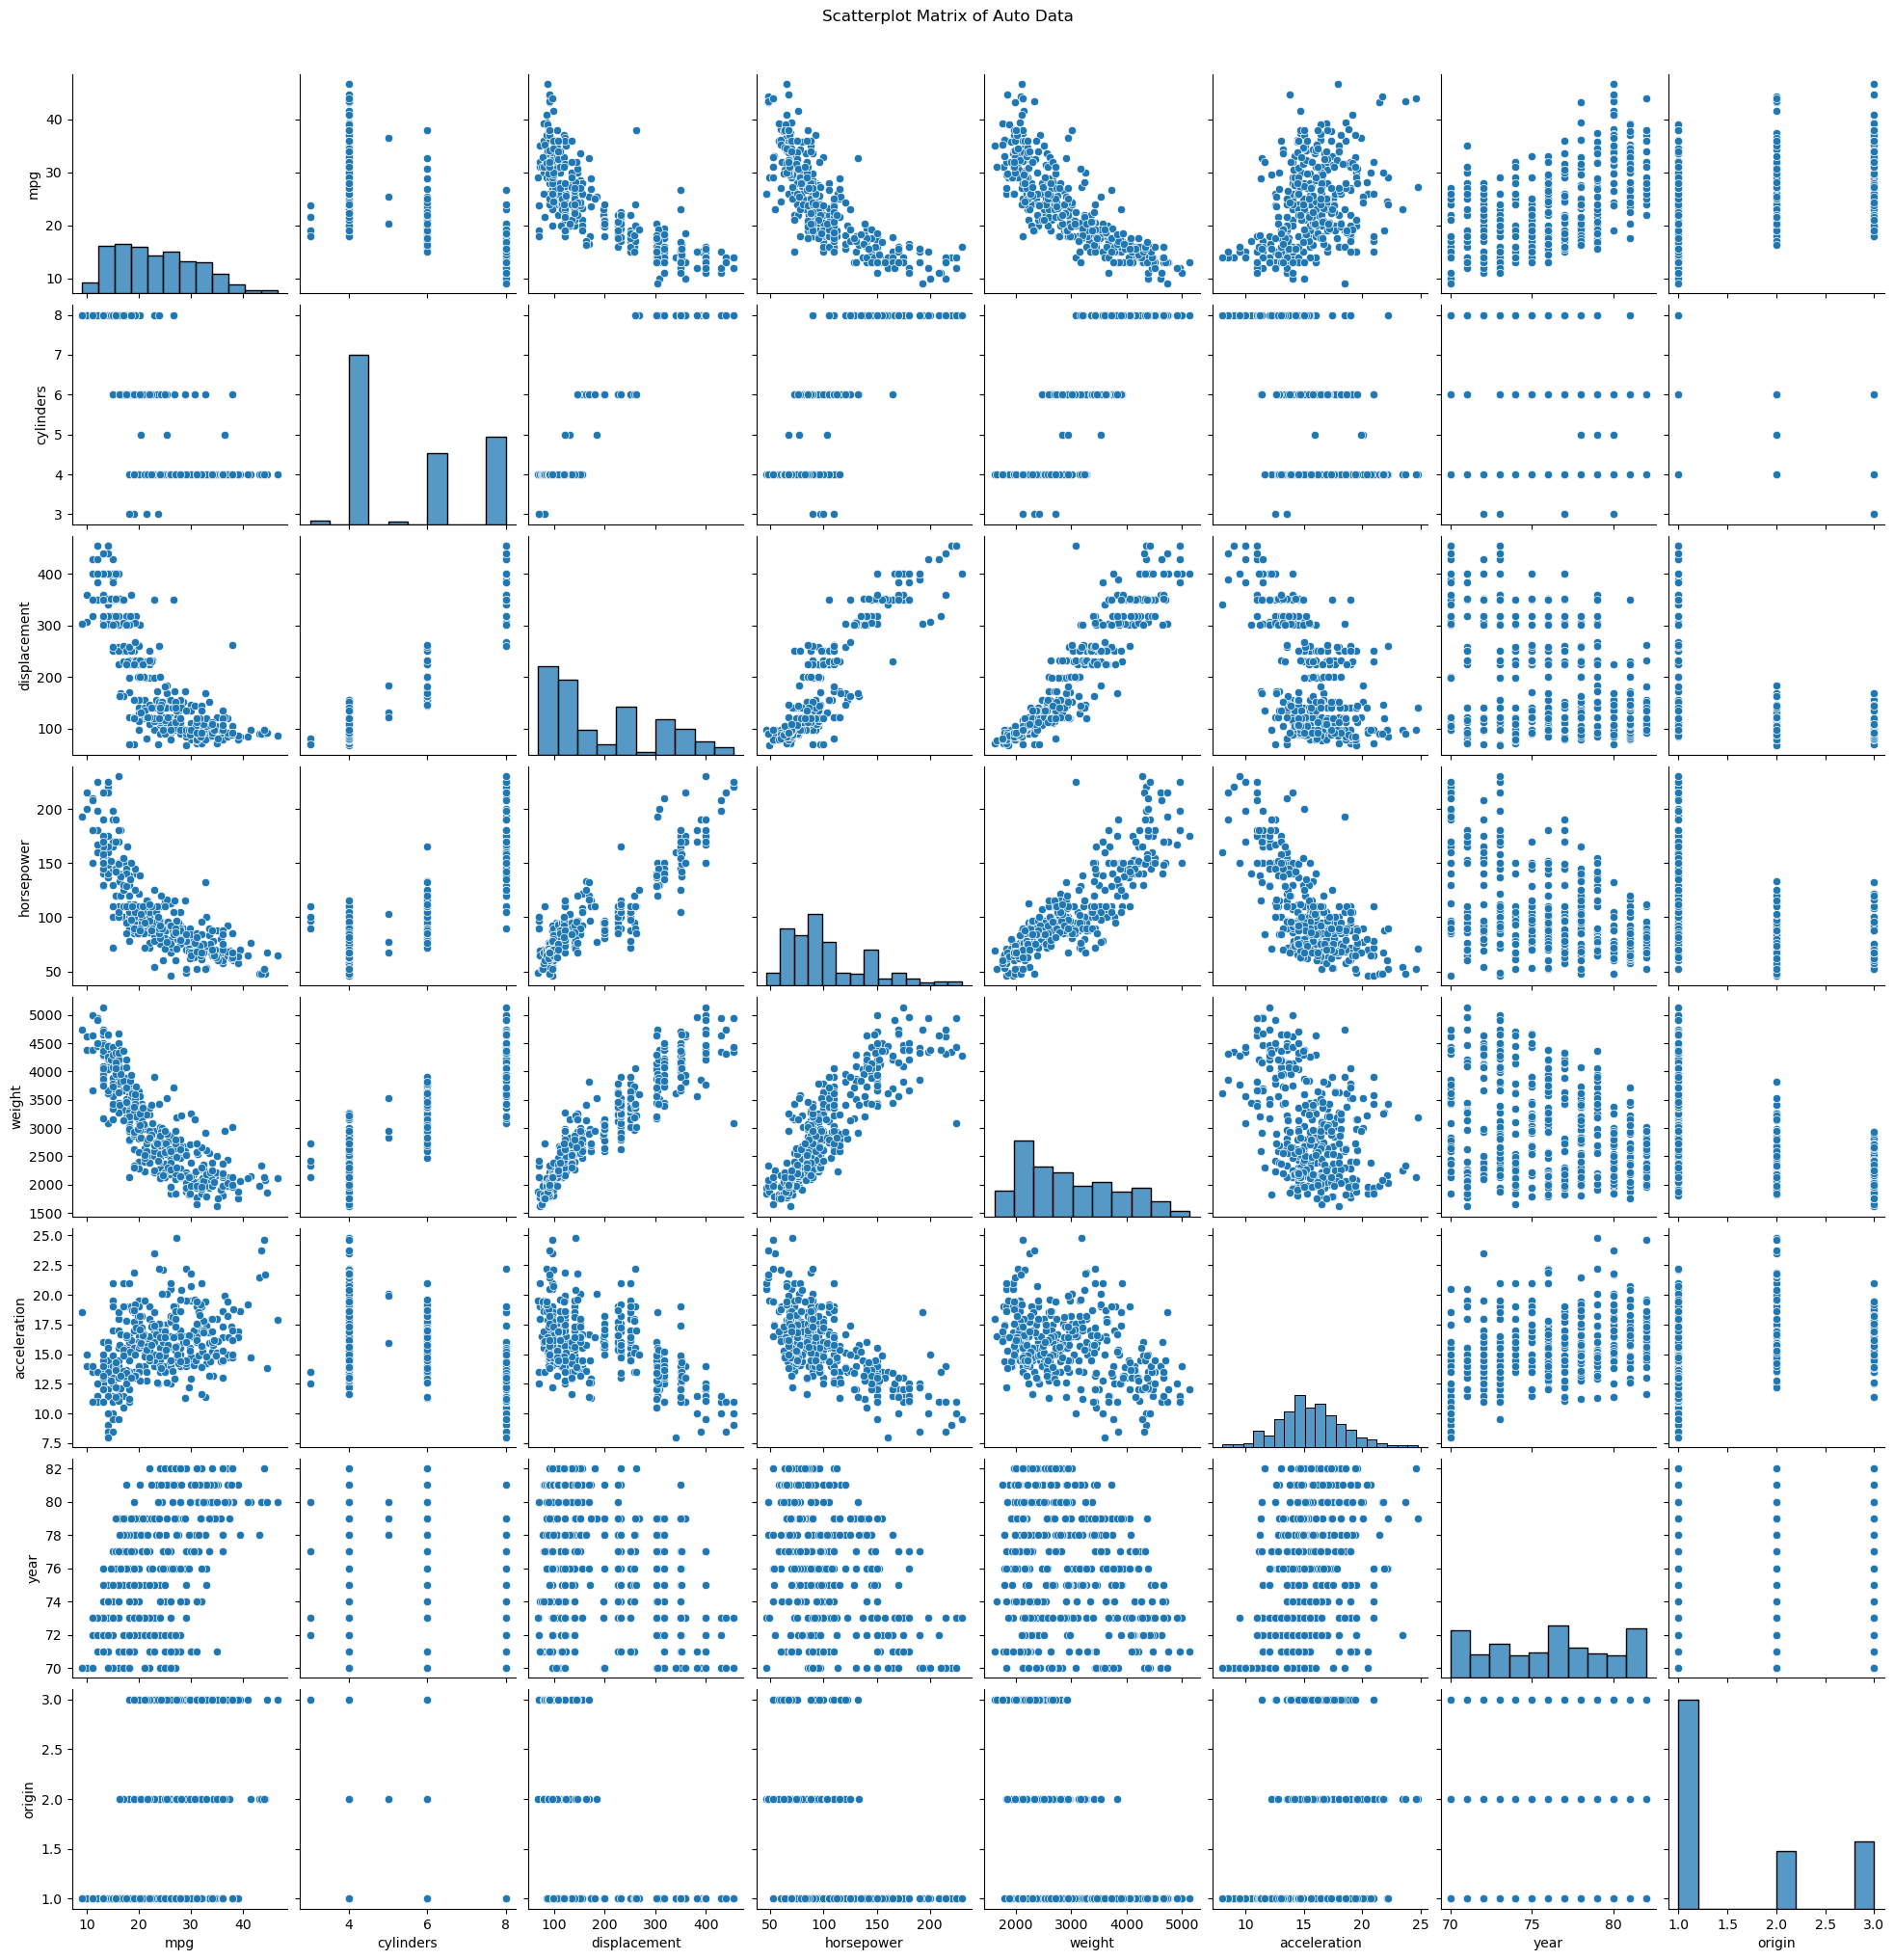

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatterplot matrix using seaborn
sns.pairplot(Auto)
plt.suptitle('Scatterplot Matrix of Auto Data', y=1.02)  # Add a title
plt.show()

#(b) Compute the matrix of correlations between the variables using the DataFrame.corr() method.

In [35]:
# Compute the correlation matrix
correlation_matrix = Auto.corr()

# Print the correlation matrix
correlation_matrix

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


#(c) Use the sm.OLS() function to perform a multiple linear regression with mpg as the response and all other variables except name as the predictors. Use the summarize() function to print the results. Comment on the output. For instance:

In [39]:
import statsmodels.formula.api as sm
# Fit the multiple linear regression model 用多個因素來預測一個結果
# 誤差項 (Error Term)： 模型無法解釋的部分，代表其他未知的因素或隨機變異，通常用 ε 表示
formula = 'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin'
model = sm.ols(formula, data=Auto).fit()

# Print the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          2.04e-139
Time:                        09:33:38   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -17.2184      4.644     -3.707   

A:

Here we apply mpg as dependant variable(to estimate the fuel efficiency of cars per gallon.
No. Observations: 392 means 392 cars for the observation.
Df Model: 7 independant variables (cylinders, displacement, horsepower, weight, acceleration, year, origin)

R-squared: 0.821 means the model can explain about 82.1% of the variation in the number of (mpg)

-->This model explains approximately 82% of the variation in vehicle fuel efficiency (mpg). Year, weight, origin, and displacement are significantly associated with fuel efficiency 

while cylinders, horsepower, and acceleration are not.

#_i. Is there a relationship between the predictors and the response? Use the anova_lm() function from statsmodels to answer this question.
.corr()

In [61]:
from statsmodels.stats.anova import anova_lm
# i. Is there a relationship between predictors and response?
anova_table = anova_lm(model, type=2) 
print("\nANOVA Table:")
print(anova_table)

# Get the F-statistic and p-value from the ANOVA table for the whole model
# (Look for the row corresponding to the entire model, not individual variables)
try:
    f_statistic = anova_table['F']['Residual'] # This line is incorrect
    p_value = anova_table['PR(>F)']['Residual'] # This line is incorrect
except KeyError:
    print("\nCould not extract F-statistic and P-value for the overall model from the ANOVA table.")
    f_statistic = None
    p_value = None

if f_statistic and p_value:  # Only proceed if we found the values
    print(f"\nF-statistic: {f_statistic:.4f}")
    print(f"P-value: {p_value:.4f}")


ANOVA Table:
                 df        sum_sq       mean_sq            F         PR(>F)
cylinders       1.0  14403.083079  14403.083079  1300.683788  2.319511e-125
displacement    1.0   1073.344025   1073.344025    96.929329   1.530906e-20
horsepower      1.0    403.408069    403.408069    36.430140   3.731128e-09
weight          1.0    975.724953    975.724953    88.113748   5.544461e-19
acceleration    1.0      0.966071      0.966071     0.087242   7.678728e-01
year            1.0   2419.120249   2419.120249   218.460900   1.875281e-39
origin          1.0    291.134494    291.134494    26.291171   4.665681e-07
Residual      384.0   4252.212530     11.073470          NaN            NaN

F-statistic: nan
P-value: nan


In [53]:
# Comment on the output
# i. Is there a relationship between the predictors and the response?
alpha = 0.05  # Significance level
if p_value < alpha:
    print("\nThere is a statistically significant relationship between the predictors and the response (mpg).")
else:
    print("\nThere is no statistically significant relationship between the predictors and the response (mpg).")


There is no statistically significant relationship between the predictors and the response (mpg).


Based on the statistical test used, there is insufficient evidence to support the predictor variables.

#_ii. Which predictors appear to have a statistically significant relationship to the response?

In [55]:
# ii. Which predictors appear to have a statistically significant relationship to the response?
print("\nSignificant predictors based on the regression summary:")
for feature in model.pvalues.keys():
    if model.pvalues[feature] < alpha:
        print(f"- {feature}")


Significant predictors based on the regression summary:
- Intercept
- displacement
- weight
- year
- origin


#_iii. What does the coefficient for the year variable suggest?

In [63]:
# iii. What does the coefficient for the year variable suggest?
year_coefficient = model.params['year']
print(f"\nThe coefficient for the 'year' variable is: {year_coefficient:.4f}")
print("This suggests that, on average, for each additional year, the mpg increases by this amount, holding other variables constant.")


The coefficient for the 'year' variable is: 0.7508
This suggests that, on average, for each additional year, the mpg increases by this amount, holding other variables constant.


According to the regression model, after controlling for factors other than the year (such as the number of cylinders, displacement, etc.), on average, the fuel efficiency (mpg) of a car will increase by 0.7508 miles per gallon for each year the car is produced later. This may be because over time, automobile manufacturing technology continues to improve, making cars more fuel efficient.

#(d) Produce some of diagnostic plots of the linear regression fit as described in the lab. Comment on any problems you see with the fit. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

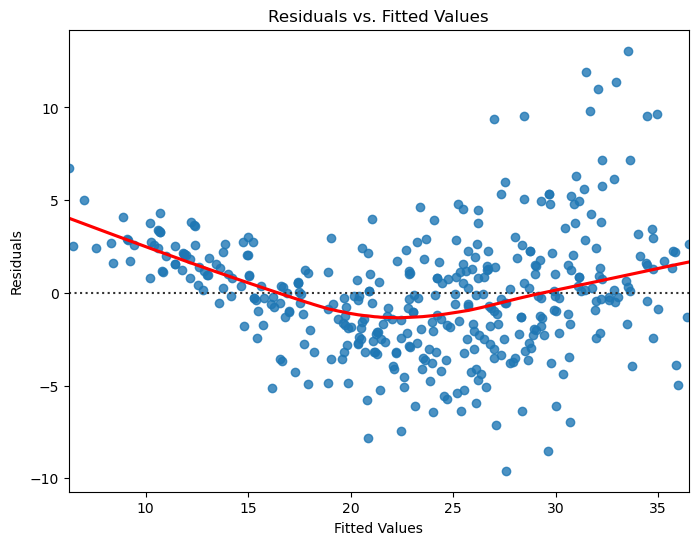

In [65]:
# Diagnostic Plots

# 1. Residuals vs. Fitted Values
plt.figure(figsize=(8, 6))
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')
plt.show()

If the linear model is appropriate, the residuals should be randomly distributed about 0. However, if there is a curvature, scalloping, or other nonrandom pattern, the linear assumption may be violated and a transformation of the variables or a nonlinear model may be necessary.

<Figure size 800x600 with 0 Axes>

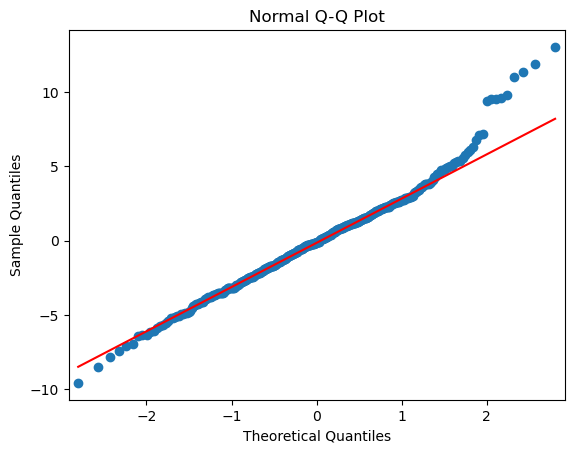

In [67]:
# 2. QQ Plot
import statsmodels.api as sm_qq
plt.figure(figsize=(8, 6))
sm_qq.qqplot(model.resid, line='q')
plt.title('Normal Q-Q Plot')
plt.show()

Ideal situation: If the sample data conforms to the normal distribution, then the points in the QQ graph should be distributed roughly along a straight line.

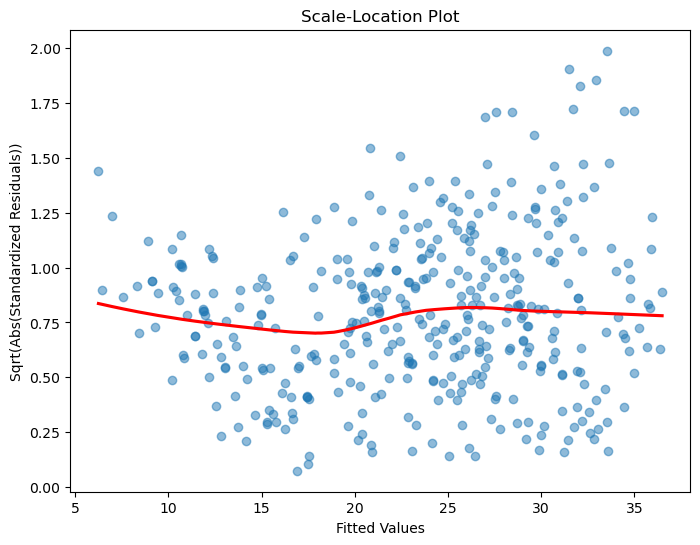

In [73]:
import numpy as np
#import statsmodels.formula.api as sm
# 3. Scale-Location Plot (Sqrt of Standardized Residuals vs. Fitted Values)
plt.figure(figsize=(8, 6))
studentized_residuals = model.get_influence().resid_studentized_internal
# 計算 Student 化殘差 (Studentized Residuals)。
#   model.get_influence(): 取得迴歸模型的影響力測度 (influence measures)。
#   .resid_studentized_internal: 取得內部 Student 化的殘差。

# 為什麼要計算 Student 化殘差？
#   Student 化殘差可以更好地檢測離群值和變異數異質性。 
#   它們會考慮到每個數據點的槓桿作用 (leverage)，也就是該數據點對迴歸模型的影響力。

plot_data = pd.DataFrame({'fitted_values': model.fittedvalues,
                          'sqrt_abs_std_residuals': np.sqrt(np.abs(studentized_residuals))})
# 建立一個名為 plot_data 的 DataFrame，包含以下欄位：
#   'fitted_values': 迴歸模型的預測值 (fitted values)。
#   'sqrt_abs_std_residuals': Student 化殘差的平方根的絕對值。

# 為什麼要對 Student 化殘差取平方根的絕對值？
#   - 平方根：將標準化殘差轉換為更易於解釋的尺度，並減少極端值的影響。
#   - 絕對值：只關心殘差的大小，不關心方向(正或負)。

plt.scatter(plot_data['fitted_values'], plot_data['sqrt_abs_std_residuals'], alpha=0.5)
# 繪製散佈圖，其中：
#   x 軸: 預測值 (fitted_values)。
#   y 軸: Student 化殘差的平方根的絕對值 (sqrt_abs_std_residuals)。
#   alpha=0.5: 設定點的透明度為 0.5。

sns.regplot(x='fitted_values', y='sqrt_abs_std_residuals', data=plot_data, scatter=False, ci=False, lowess=True, line_kws={'color': 'red'})
# 使用 seaborn 的 regplot 函數添加一條平滑曲線到圖中。
#   x='fitted_values': 將 'fitted_values' 欄位作為 x 軸。
#   y='sqrt_abs_std_residuals': 將 'sqrt_abs_std_residuals' 欄位作為 y 軸。
#   data=plot_data: 指定要使用的数据是plot_data DataFrame。
#   scatter=False: 不顯示散佈點。我們已經用 plt.scatter 繪製了散佈點。
#   ci=False: 不顯示信賴區間 (confidence interval)。
#   lowess=True: 使用 LOWESS (Locally Weighted Scatterplot Smoothing) 方法添加一條平滑曲線到圖中。
#   line_kws={'color': 'red'}: 設定 LOWESS 曲線的顏色為紅色。

plt.xlabel('Fitted Values')
# 設定 x 軸標籤為 "Fitted Values" (預測值)。
plt.ylabel('Sqrt(Abs(Standardized Residuals))')
# 設定 y 軸標籤為 "Sqrt(Abs(Standardized Residuals))" (標準化殘差的平方根的絕對值)。
plt.title('Scale-Location Plot')
plt.show()


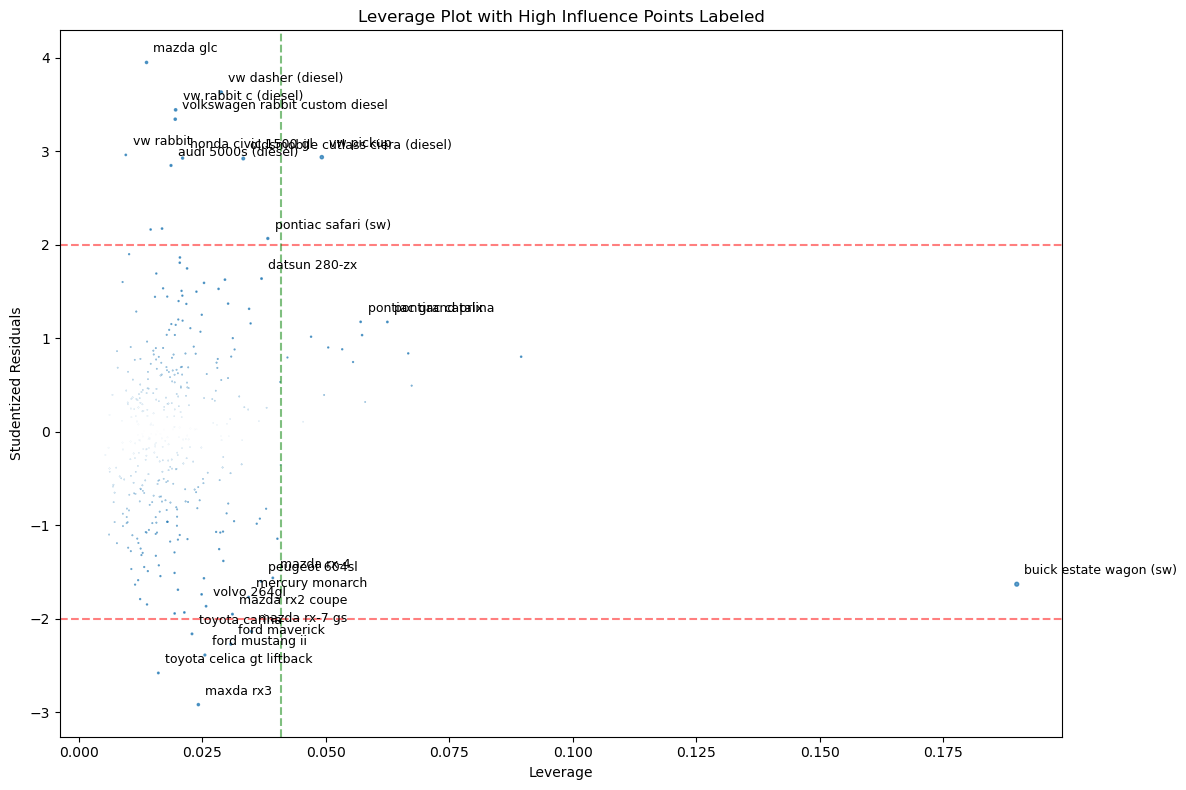

In [95]:
# 4. Leverage Plot
# 4. 槓桿圖 (影響圖)

plt.figure(figsize=(12, 8))  # Larger figure size
# 建立一個新的圖形，設定大小為寬 12 英吋、高 8 英吋。
# 增加圖形大小，提供更多空間放置點和標籤。

# Get influence measures
# 取得影響力測量值
influence = model.get_influence()
# 取得迴歸模型 (model) 的影響力測度。

cooks_distances = influence.cooks_distance[0]
# 取得 Cook's 距離 (Cook's Distance)。
# Cook's 距離衡量移除某個數據點後，迴歸模型發生多大變化的指標。

standardized_residuals = influence.resid_studentized_internal
# 取得內部 Student 化的殘差 (Studentized Residuals)。
# Student 化的殘差是經過標準化的殘差，可以更好地檢測離群值。

leverage = influence.hat_matrix_diag
# 取得槓桿值 (leverage)。
# 槓桿值衡量一個數據點對迴歸模型的影響力，數值越高，代表該點對模型的影响越大。
# 槓桿值由帽子矩陣 (hat matrix) 的對角線元素表示。

# Create DataFrame for plotting
# 建立用於繪圖的 DataFrame
influence_df = pd.DataFrame({'leverage': leverage,
                             'studentized_residuals': standardized_residuals,
                             'cooks_distance': cooks_distances,
                             'name': Auto.index}) #Keep track of car name
# 建立一個名為 influence_df 的 DataFrame，包含以下欄位：
#   'leverage': 槓桿值。
#   'studentized_residuals': Student 化殘差。
#   'cooks_distance': Cook's 距離。
#   'name': Auto.index，保留車輛的名稱，以便在圖中標記。

# Set threshold for Cook's distance
# 設定 Cook's 距離的閾值
cooks_threshold = 4 / len(Auto)
# 設定 Cook's 距離的閾值。
# 常用的閾值是 4 / n，其中 n 是數據點的數量。
# 閾值用於識別有高影響力的點。

# Plot influence plot without labels initially
# 先繪製影響圖，不添加標籤
plt.scatter(influence_df['leverage'], influence_df['studentized_residuals'], s=100 * influence_df['cooks_distance'], alpha=0.7)
# 繪製散佈圖，其中：
#   x 軸: 槓桿值 (leverage)。
#   y 軸: Student 化殘差 (studentized_residuals)。
#   s=100 * influence_df['cooks_distance']: 點的大小與 Cook's 距離成正比。
#   alpha=0.7: 設定點的透明度為 0.7。
# 先繪製散佈圖，不添加標籤，可以避免標籤重疊的問題。

# Identify potential high influence points
# 識別潛在的高影響力點
high_influence = influence_df[influence_df['cooks_distance'] > cooks_threshold]
# 篩選出 Cook's 距離大於閾值的數據點，這些數據點被認為是有高影響力的點。

# Add labels only for high influence points
# 只為高影響力點添加標籤
for i, row in high_influence.iterrows():
    plt.annotate(row['name'], xy=(row['leverage'], row['studentized_residuals']), xytext=(5, 5),
                 textcoords='offset points', ha='left', va='bottom', fontsize=9)  # Reduced fontsize
# 遍歷 high_influence DataFrame 中的每一行，為每個高影響力點添加標籤。
#   row['name']: 標籤的文字是車輛的名稱。
#   xy=(row['leverage'], row['studentized_residuals']): 標籤的位置是該點的槓桿值和 Student 化殘差。
#   xytext=(5, 5): 設定標籤的偏移量。
#   textcoords='offset points': 設定偏移量的單位為點。
#   ha='left', va='bottom': 設定標籤的水平和垂直對齊方式。
#   fontsize=9: 設定標籤的字體大小為 9。
# 只為高影響力點添加標籤，可以減少標籤重疊的問題。

# Add labels and thresholds
# 添加標籤和閾值線
plt.xlabel('Leverage')
# 設定 x 軸標籤為 "Leverage" (槓桿值)。

plt.ylabel('Studentized Residuals')
# 設定 y 軸標籤為 "Studentized Residuals" (Student 化殘差)。

plt.title('Leverage Plot with High Influence Points Labeled')
# 設定圖形的標題為 "Leverage Plot with High Influence Points Labeled" (標記了高影響力點的槓桿圖)。

plt.axhline(y=2, color='r', linestyle='--', alpha=0.5)
# 添加水平線，表示 Student 化殘差的閾值。
#   y=2: 水平線的位置是 y = 2。
#   color='r': 設定線的顏色為紅色。
#   linestyle='--': 設定線的樣式為虛線。
#   alpha=0.5: 設定線的透明度為 0.5。
# Student 化殘差大於 2 或小於 -2 的點被認為是離群值。

plt.axhline(y=-2, color='r', linestyle='--', alpha=0.5)
# 添加水平線，表示 Student 化殘差的閾值。

plt.axvline(x=2*np.mean(leverage), color='g', linestyle='--', alpha=0.5) # Add line for mean leverage
# 添加垂直線，表示槓桿值的平均值的兩倍。
# x=2*np.mean(leverage)：線的位置為槓桿平均值的兩倍

# Tight layout and show plot
# 調整佈局並顯示圖形
plt.tight_layout()
# 自動調整子圖參數，以提供足夠的空間，減少重疊。

plt.show()
# 顯示圖形。

--> High Leverage Points: Focus on points with large x-axis (leverage values). These points have different values ​​for the independent variable than the other data points and therefore are likely to have a larger impact on the regression model.

--> Outliers: Focus on points on the y-axis (Studentized residuals) that have large values. These points have large residuals, indicating a large difference between the actual and predicted values.

--> Influential Points: Focus on points with both high leverage values ​​and large Studentized residuals. These points have a large influence on the regression model, and removing them may significantly change the model. Points with large Cook's distances are generally considered influential.

In [79]:
# Identifying Outliers and High Leverage Points

# Outliers (using studentized residuals)
outlier_threshold = 2  # Common threshold for outliers
outliers = Auto[np.abs(studentized_residuals) > outlier_threshold]
print("\nPotential Outliers (Studentized Residuals > {}):\n".format(outlier_threshold), outliers.index.tolist())


Potential Outliers (Studentized Residuals > 2):
 ['pontiac safari (sw)', 'toyota carina', 'maxda rx3', 'ford maverick', 'ford mustang ii', 'volkswagen rabbit custom diesel', 'datsun b210 gx', 'toyota celica gt liftback', 'vw rabbit', 'mazda glc', 'datsun 210', 'vw rabbit c (diesel)', 'vw dasher (diesel)', 'audi 5000s (diesel)', 'honda civic 1500 gl', 'mazda rx-7 gs', 'oldsmobile cutlass ciera (diesel)', 'vw pickup']


--> This list tells that the actual fuel efficiency (mpg) of the cars listed in regression model differs significantly from the fuel efficiency predicted by the model based on other variables (e.g., number of cylinders, displacement, etc.).

--> These cars have unusually high or low mpg values, causing their Studentized residuals to exceed the decided threshold of 2.

In [81]:
# High Leverage Points (using Cook's distance)
influence = model.get_influence()
cooks_distance = influence.cooks_distance[0]
leverage_threshold = 4 / len(Auto)  # Common threshold for high leverage
high_leverage_points = Auto[cooks_distance > leverage_threshold]
print("\nHigh Leverage Points (Cook's Distance > {}):\n".format(leverage_threshold), high_leverage_points.index.tolist())


High Leverage Points (Cook's Distance > 0.01020408163265306):
 ['pontiac catalina', 'buick estate wagon (sw)', 'pontiac safari (sw)', 'mazda rx2 coupe', 'toyota carina', 'maxda rx3', 'pontiac grand prix', 'mercury monarch', 'ford maverick', 'ford mustang ii', 'mazda rx-4', 'volkswagen rabbit custom diesel', 'toyota celica gt liftback', 'volvo 264gl', 'peugeot 604sl', 'vw rabbit', 'mazda glc', 'vw rabbit c (diesel)', 'vw dasher (diesel)', 'audi 5000s (diesel)', 'honda civic 1500 gl', 'datsun 280-zx', 'mazda rx-7 gs', 'oldsmobile cutlass ciera (diesel)', 'vw pickup']


High Leverage Points: These are data points where the predicted variable values ​​(e.g., number of cylinders, displacement, etc.) are very unusual.

High Leverage Points' feature combinations are different from most other data points in the dataset.

#(e) Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant?

In [97]:
# Fit the multiple linear regression model without interactions (base model)
formula_base = 'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin'
model_base = sm.ols(formula_base, data=Auto).fit()
print("Base Model Summary:\n", model_base.summary())

# Fit the model with an interaction between year and horsepower
formula_interaction1 = 'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin + year:horsepower'
model_interaction1 = sm.ols(formula_interaction1, data=Auto).fit()
print("\nModel with year:horsepower Interaction Summary:\n", model_interaction1.summary())

# Fit the model with an interaction between year and weight
formula_interaction2 = 'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin + year:weight'
model_interaction2 = sm.ols(formula_interaction2, data=Auto).fit()
print("\nModel with year:weight Interaction Summary:\n", model_interaction2.summary())

# Fit the model with interactions between year and all other variables
formula_interaction_all = 'mpg ~ (cylinders + displacement + horsepower + weight + acceleration + origin)*year'
model_interaction_all = sm.ols(formula_interaction_all, data=Auto).fit()
print("\nModel with Interactions between year and all other variables:\n", model_interaction_all.summary())

# Determine statistically significant interactions
alpha = 0.05  # Significance level

print("\nStatistically Significant Interactions:")
if 'year:horsepower' in model_interaction1.pvalues and model_interaction1.pvalues['year:horsepower'] < alpha:
    print("- year:horsepower")
if 'year:weight' in model_interaction2.pvalues and model_interaction2.pvalues['year:weight'] < alpha:
    print("- year:weight")

# Check for interactions in the all variable model
for term in model_interaction_all.pvalues.keys():
    if ":" in term and model_interaction_all.pvalues[term] < alpha:
        print(f"- {term}")

Base Model Summary:
                             OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          2.04e-139
Time:                        11:05:53   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -17.2184    

** Find pvalue<0.05

--> The effect of horsepower on mpg varies by year.

--> The effect of weight on mpg varies by year.

-->The effect of acceleration on mpg varies by year.

#(f) Try a few different transformations of the variables, such as log(X), √X, X2. Comment on your findings.

In [101]:
# --- Original Model ---
print("Original Model:")
formula_original = 'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin'
model_original = sm.ols(formula_original, data=Auto).fit()
print(model_original.summary())

# --- Log Transformation ---
print("\nLog Transformation (log(horsepower)):")
Auto['log_horsepower'] = np.log(Auto['horsepower'])  # Create a new column
formula_log = 'mpg ~ cylinders + displacement + log_horsepower + weight + acceleration + year + origin'
model_log = sm.ols(formula_log, data=Auto).fit()
print(model_log.summary())

# --- Square Root Transformation ---
print("\nSquare Root Transformation (sqrt(weight)):")
Auto['sqrt_weight'] = np.sqrt(Auto['weight'])  # Create a new column
formula_sqrt = 'mpg ~ cylinders + displacement + horsepower + sqrt_weight + acceleration + year + origin'
model_sqrt = sm.ols(formula_sqrt, data=Auto).fit()
print(model_sqrt.summary())

# --- Squared Transformation ---
print("\nSquared Transformation (year^2):")
Auto['year_squared'] = Auto['year']**2  # Create a new column
formula_squared = 'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + year_squared + origin'
model_squared = sm.ols(formula_squared, data=Auto).fit()
print(model_squared.summary())

Original Model:
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          2.04e-139
Time:                        11:14:39   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -17.2184      4.6

@Original Model（原始模型）：
 R-squared 為 0.821，代表模型可以解釋大約 82.1% 的 mpg 變異。
高條件數 (8.59e+04) 表示可能存在多重共線性問題，這會影響係數估計的準確性。
這是評估其他模型的基準。

@Log Transformation (log(horsepower))（對數轉換 (horsepower)）：
R-squared 提升到 0.837，略高於原始模型。
AIC 和 BIC 值降低，表示模型在複雜度和擬合度之間取得了更好的平衡。
log_horsepower 的 p 值非常小 (0.000)，表示此轉換後變數顯著影響 mpg。
條件數增加到 1.68e+05，表示多重共線性問題可能更嚴重。
結論：對 horsepower 進行對數轉換似乎可以略微改善模型的擬合度，但可能加劇多重共線性問題。

@Square Root Transformation (sqrt(weight))（平方根轉換 (weight)）：
R-squared 提升到 0.836，略高於原始模型。
AIC 和 BIC 值降低，表示模型在複雜度和擬合度之間取得了更好的平衡。
sqrt_weight 的 p 值非常小 (0.000)，表示此轉換後變數顯著影響 mpg。
條件數降低到 7.27e+03，表示多重共線性問題可能有所緩解。
結論：對 weight 進行平方根轉換似乎可以略微改善模型的擬合度，並可能降低多重共線性問題。

@Squared Transformation (year)（平方轉換 (year)）：
R-squared 提升到 0.834，但提升幅度最小。
AIC 和 BIC 值增加，表示模型在複雜度和擬合度之間的平衡較差，可能存在過度擬合。
year_squared 的 p 值非常小 (0.000)，表示此轉換後變數顯著影響 mpg，但同時 year 也顯著。
條件數極高 (3.23e+06)，表示存在非常嚴重的多重共線性問題。
結論：對 year 進行平方轉換可能並不明智，雖然提高了解釋力，但引入了更嚴重的多重共線性問題，並且可能導致過度擬合。

@@ 總結：
對 horsepower 進行對數轉換和對 weight 進行平方根轉換都略微改善了模型的擬合度 (R-squared 增加，AIC/BIC 降低)。
但重要的是要考慮多重共線性問題。 平方根轉換 weight 似乎是最好的選擇，因為它在略微提高模型擬合度的同時，還降低了多重共線性。
添加 year 的平方項似乎沒有帶來明顯的好處，反而加劇了多重共線性問題。
在選擇最終模型時，還需要考慮殘差的診斷圖，以檢查是否存在非線性、非常數變異數或非常態性等問題。

@建議：
檢查殘差圖： 對所有模型繪製殘差圖 (Residuals vs Fitted Values、QQ Plot 等)，以檢查模型的假設是否成立。
仔細評估多重共線性： 計算 VIF (變異數膨脹因子) 以量化多重共線性程度，並考慮使用懲罰迴歸 (例如 Ridge 迴歸) 來緩解多重共線性帶來的影響。
謹慎選擇模型： 選擇模型時，不僅要考慮 R-squared，還要考慮 AIC、BIC 和殘差圖，以及模型的解釋能力和簡潔性。 在這個案例中，如果診斷圖沒有顯示任何重大問題，並且模型的可解釋性不變，那麼使用平方根轉換 weight 的模型似乎是最好的選擇。